# Strategic Client Segmentation: A Hypothesis-Driven Approach
1. Business Context & Hypothesis

Instead of relying on algorithm-driven, black-box clustering that often yields generic profiles (e.g., "High", "Medium", "Low" wealth), this analysis employs a Top-Down, Hypothesis-Driven framework.

The Core Hypothesis: We postulate that a client's financial lifecycle and profitability can be modeled using three synthetic dimensions:

    Financial Literacy: A composite of financial education, digital adoption, and job complexity.

    Debt Cycle Stress: The burden of debt relative to accumulated wealth and income.

    Management Proactivity: The balance between proactive wealth-building (savings/investments) and passive consumption (luxury).

We will engineer these pillars, cluster the clients, and validate if these hypothesized segments form actionable business personas.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.graph_objects as go

In [2]:
# --- 1. LOAD DATA ---

path = "./Dataset1_BankClients.xlsx"
df = pd.read_excel(path)

In [3]:
# Drop the column by its actual name (e.g., 'ID' or the actual name of the column)
df = df.drop(columns=['ID'])  # Replace 'ID' with the actual column name to drop

# Let's inspect the first 5 record
df.head()

,Age,Gender,Job,Area,CitySize,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Investments
0,24,1,1,2,2,4,0.668046,0.702786,0.262070,0.741853,0.483684,0.698625,0.618259,0.607877,0.897369,0.283222,1
1,47,1,2,2,3,1,0.858453,0.915043,0.730430,0.859423,0.537167,0.959025,0.785936,0.862271,0.913729,0.821590,3
2,38,0,2,1,2,2,0.926818,0.898316,0.441272,0.485953,0.649434,0.750265,0.699725,0.755404,0.765199,0.503790,3
3,67,0,2,1,2,3,0.538797,0.423180,0.600401,0.493144,0.533829,0.590165,0.675353,0.334432,0.517209,0.691240,2
4,33,0,2,1,3,1,0.806659,0.731404,0.831449,0.856286,0.784940,0.710026,0.758793,0.908878,0.611610,0.615916,2


# Data Loading & Preprocessing

First, we load the data and map the categorical variables into mathematically usable ordinal scales based on their "financial weight."

In [4]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# ==========================================
# STEP 2: SCALING THE REMAINING RAW CATEGORIES
# ==========================================
# Age, FamilySize, Job (1-5), and Investments (1-3) are NOT percentiles.
# We will use MinMaxScaler to push them to a 0.0 - 1.0 scale so they 
# match the percentile format of the other variables.

scaler = MinMaxScaler()
# Assuming your percentiles are 0-100, we scale everything to 0-1 for clean math
# (If your percentiles are already 0.0-1.0, this scaler won't hurt them, it just ensures consistency)

cols_to_scale = ['Job', 'Investments', 'Income', 'Wealth', 'Debt', 
                 'FinEdu', 'Digital', 'BankFriend', 'Saving', 'Luxury', 'ESG']

df_scaled = pd.DataFrame(scaler.fit_transform(df[cols_to_scale]), columns=cols_to_scale)

# ==========================================
# STEP 3: CONSTRUCTING THE PILLARS (Corrected Dimensions)
# ==========================================
# FIX 1: Give the new DataFrame the exact same index (row numbers) as your original data
df_pillars = pd.DataFrame(index=df.index) 

# --- PILLAR 1: Debt Cycle Stress (Subtractive instead of Division) ---
raw_debt_stress = df_scaled['Debt'] - ((df_scaled['Income'] + df_scaled['Wealth']) / 2)

# FIX 2: Add .flatten() to convert the (5000, 1) 2D array back into a flat 1D column
df_pillars['Debt_Cycle_Stress'] = MinMaxScaler().fit_transform(raw_debt_stress.values.reshape(-1, 1)).flatten()

# --- PILLAR 2: Financial Literacy (Additive) ---
df_pillars['Financial_Literacy'] = df_scaled[['FinEdu', 'Digital', 'BankFriend', 'Job']].mean(axis=1)

# --- PILLAR 3: Management Approach (Additive) ---
raw_management = (df_scaled['Saving'] + df_scaled['Investments'] + df_scaled['ESG']) - df_scaled['Luxury']
df_pillars['Management_Approach'] = MinMaxScaler().fit_transform(raw_management.values.reshape(-1, 1)).flatten()

print("Feature Engineering Complete. Shape of Pillars:", df_pillars.shape)

Feature Engineering Complete. Shape of Pillars: (5000, 3)


In [17]:
df_pillars.head()

,Debt_Cycle_Stress,Financial_Literacy,Management_Approach
0,0.306469,0.517842,0.180195
1,0.492275,0.727127,0.665319
2,0.275241,0.551093,0.646708
3,0.678438,0.504614,0.592330
4,0.641724,0.654281,0.620484


In [5]:
import plotly.express as px
from sklearn.mixture import GaussianMixture

# ==========================================
# STEP 4: GMM CLUSTERING & 3D VISUALIZATION
# ==========================================

# 1. Fit the Gaussian Mixture Model (Targeting 5 business personas)
gmm = GaussianMixture(n_components=5, covariance_type='full', random_state=42, n_init=10)
df_pillars['Persona_ID'] = gmm.fit_predict(df_pillars)

# Convert Persona_ID to a string so Plotly treats it as distinct categories (colors), 
# rather than a continuous numeric gradient.
df_pillars['Persona_ID'] = df_pillars['Persona_ID'].astype(str)

# 2. Build the 3D Interactive Scatter Plot
fig = px.scatter_3d(
    df_pillars, 
    x='Financial_Literacy', 
    y='Debt_Cycle_Stress', 
    z='Management_Approach',
    color='Persona_ID',
    title='3D Geometry of Customer Personas (GMM Clusters)',
    opacity=0.7,             # Slight transparency so you can see overlapping dots
    color_discrete_sequence=px.colors.qualitative.Bold  # Professional color palette
)

# 3. Optimize the layout for a professional presentation
fig.update_traces(marker=dict(size=4, line=dict(width=0.5, color='DarkSlateGrey')))
fig.update_layout(
    scene=dict(
        xaxis_title='Financial Literacy',
        yaxis_title='Debt Cycle Stress',
        zaxis_title='Management Approach'
    ),
    margin=dict(l=0, r=0, b=0, t=40), # Removes unnecessary white space
    legend_title_text='GMM Persona'
)

# Display the interactive plot!
fig.show()

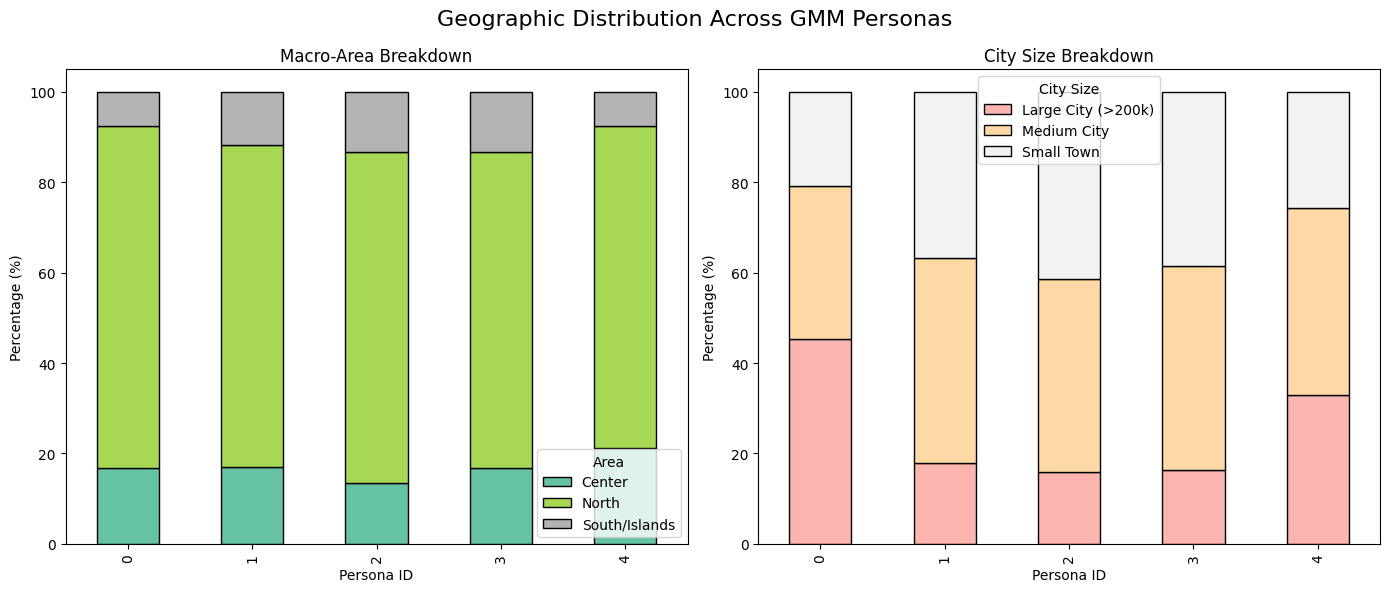

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# STEP 5: GEOGRAPHIC PROFILING OF PERSONAS
# ==========================================
# We map the numeric codes back to readable labels for the chart
area_map = {1: 'North', 2: 'Center', 3: 'South/Islands'}
city_map = {1: 'Small Town', 2: 'Medium City', 3: 'Large City (>200k)'}

df['Area_Label'] = df['Area'].map(area_map)
df['City_Label'] = df['CitySize'].map(city_map)

# Put the Persona_ID from our pillars dataframe back into the main dataframe
df['Persona_ID'] = df_pillars['Persona_ID']

# Create a 1x2 subplot for Area and CitySize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Geographic Distribution Across GMM Personas', fontsize=16)

# Plot 1: Area (North vs Center vs South)
crosstab_area = pd.crosstab(df['Persona_ID'], df['Area_Label'], normalize='index') * 100
crosstab_area.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2', edgecolor='black')
axes[0].set_title('Macro-Area Breakdown')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xlabel('Persona ID')
axes[0].legend(title='Area')

# Plot 2: City Size
crosstab_city = pd.crosstab(df['Persona_ID'], df['City_Label'], normalize='index') * 100
crosstab_city.plot(kind='bar', stacked=True, ax=axes[1], colormap='Pastel1', edgecolor='black')
axes[1].set_title('City Size Breakdown')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xlabel('Persona ID')
axes[1].legend(title='City Size')

plt.tight_layout()
plt.show()

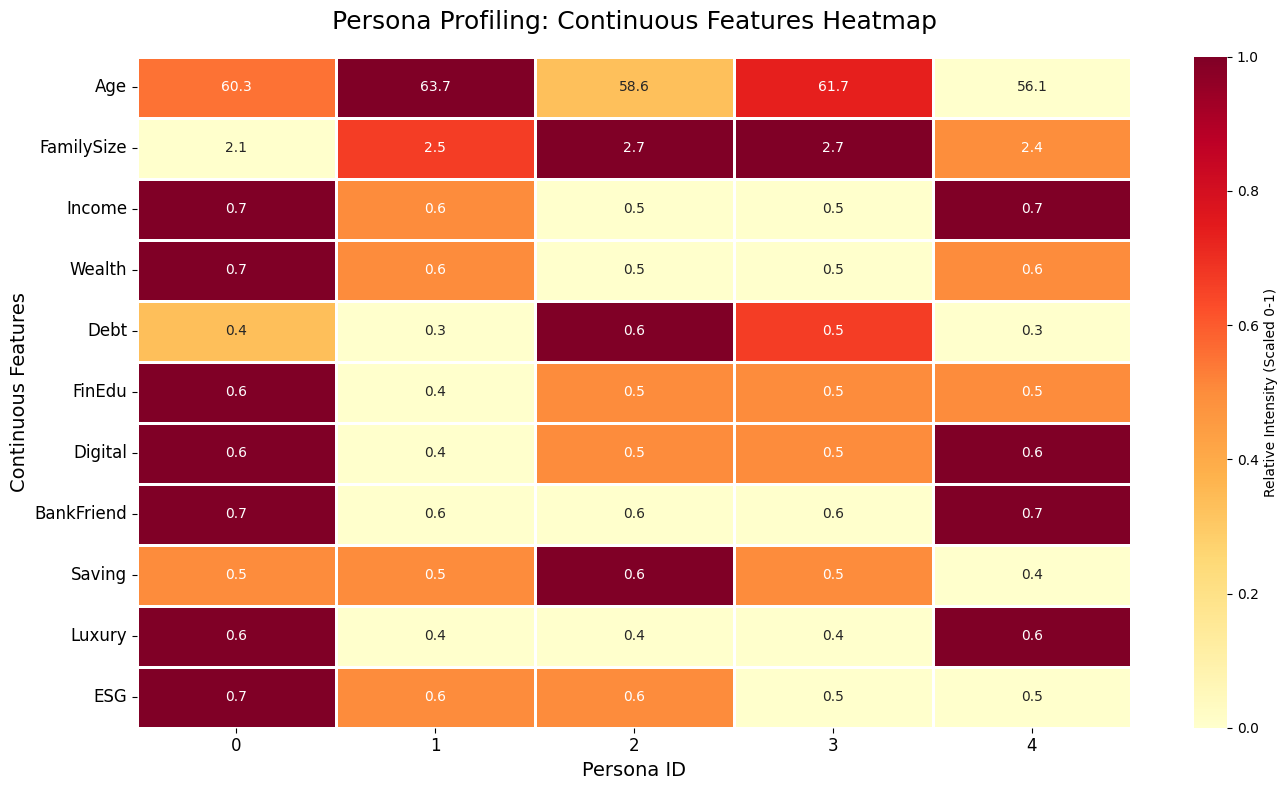

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# ==========================================
# STEP 5A: THE CONTINUOUS FEATURE HEATMAP
# ==========================================
# 1. Define only the continuous/percentile columns
continuous_cols = ['Age', 'FamilySize', 'Income', 'Wealth', 'Debt', 
                   'FinEdu', 'Digital', 'BankFriend', 'Saving', 'Luxury', 'ESG']

# 2. Calculate the true means for the annotations (the numbers written in the boxes)
cluster_means = df.groupby('Persona_ID')[continuous_cols].mean().round(1)

# 3. Scale the means strictly for the background colors (so Age doesn't distort Percentiles)
scaler_viz = MinMaxScaler()
cluster_means_scaled = pd.DataFrame(
    scaler_viz.fit_transform(cluster_means), 
    columns=cluster_means.columns, 
    index=cluster_means.index
)

# 4. Plot the Heatmap
plt.figure(figsize=(14, 8))
plt.title("Persona Profiling: Continuous Features Heatmap", fontsize=18, pad=20)

# We use the scaled data for 'data' (colors), but the raw data for 'annot' (text)
sns.heatmap(
    cluster_means_scaled.T, 
    cmap="YlOrRd",           # Yellow to Red color scale
    annot=cluster_means.T,   # Show the actual real-world numbers!
    fmt=".1f", 
    linewidths=1,
    cbar_kws={'label': 'Relative Intensity (Scaled 0-1)'}
)

plt.xlabel("Persona ID", fontsize=14)
plt.ylabel("Continuous Features", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
# ==========================================
# STEP 5: STATISTICALLY SOUND PROFILING
# ==========================================
# Ensure Persona_ID is in your main dataframe
df['Persona_ID'] = df_pillars['Persona_ID']

# 1. CONTINUOUS & PERCENTILE FEATURES -> Calculate the Mean
continuous_cols = ['Age', 'FamilySize', 'Income', 'Wealth', 'Debt', 
                   'FinEdu', 'Digital', 'BankFriend', 'Saving', 'Luxury', 'ESG']

print("--- AVERAGE PROFILE (Continuous Features) ---")
cluster_means = df.groupby('Persona_ID')[continuous_cols].mean().round(1)
display(cluster_means.T)

# 2. CATEGORICAL FEATURES -> Calculate the Mode (Most Frequent Category)
categorical_cols = ['Gender', 'Job', 'Investments', 'Area', 'CitySize']

print("\n--- MAJORITY PROFILE (Categorical Features) ---")
# Using lambda to grab the mode (the most common value) for each cluster
cluster_modes = df.groupby('Persona_ID')[categorical_cols].agg(lambda x: x.mode().iloc[0])

# Optional: Map the numbers back to words so it's readable for the business!
job_map_rev = {1: 'Unemployed', 2: 'Employee', 3: 'Manager', 4: 'Freelance', 5: 'Retired'}
inv_map_rev = {1: 'None', 2: 'Lump Sum', 3: 'Accumulation'}
area_map_rev = {1: 'North', 2: 'Center', 3: 'South'}
city_map_rev = {1: 'Small', 2: 'Medium', 3: 'Large'}

cluster_modes['Job'] = cluster_modes['Job'].map(job_map_rev)
cluster_modes['Investments'] = cluster_modes['Investments'].map(inv_map_rev)
cluster_modes['Area'] = cluster_modes['Area'].map(area_map_rev)
cluster_modes['CitySize'] = cluster_modes['CitySize'].map(city_map_rev)

display(cluster_modes.T)

--- AVERAGE PROFILE (Continuous Features) ---


Persona_ID,0,1,2,3,4
Age,60.3,63.7,58.6,61.7,56.1
FamilySize,2.1,2.5,2.7,2.7,2.4
Income,0.7,0.6,0.5,0.5,0.7
Wealth,0.7,0.6,0.5,0.5,0.6
Debt,0.4,0.3,0.6,0.5,0.3
FinEdu,0.6,0.4,0.5,0.5,0.5
Digital,0.6,0.4,0.5,0.5,0.6
BankFriend,0.7,0.6,0.6,0.6,0.7
Saving,0.5,0.5,0.6,0.5,0.4
Luxury,0.6,0.4,0.4,0.4,0.6



--- MAJORITY PROFILE (Categorical Features) ---


Persona_ID,0,1,2,3,4
Gender,0,1,1,1,1
Job,Employee,Employee,Employee,Employee,Employee
Investments,Lump Sum,Accumulation,Accumulation,None,None
Area,North,North,North,North,North
CitySize,Large,Medium,Medium,Medium,Medium
